## 1. Setup and Imports

In [1]:
# Add project root to path
import sys
from pathlib import Path

project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))
print(f"Added {project_root} to Python path")

Added /myhome/sdate to Python path


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader
from pathlib import Path
import lovely_tensors as lt
from tqdm.auto import tqdm

# Import our dataset classes
from sdate.datasets.projection_triplet_dataset import (
    ProjectionTripletDataset,
    TomographyFolderProcessor,
    create_train_val_split,
    load_tomography_params
)

# Set up lovely_tensors for better tensor visualization
lt.monkey_patch()

# Set up matplotlib
plt.rcParams['figure.figsize'] = (14, 10)
plt.rcParams['image.cmap'] = 'gray'

print("✅ Libraries imported successfully!")

/opt/conda/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Install with: pip install pillow-heif
✅ Libraries imported successfully!


## 2. Configure Data Paths

Set the path(s) to your tomographic data folders. Each folder should contain:
- Dark field images (first `num_darks` files)
- Flat field images (next `num_flats` files)
- Projection images (remaining files)

In [3]:
# Configuration
# =============

# Multiple folder example
DATA_PATH = [Path(f'/myhome/data/sdate/shared/compression_paper/file_{i}_extracted') for i in range(1, 13)]

# Or single folder (uncomment and modify as needed)
# DATA_PATH = Path('/myhome/data/sdate/shared/compression_paper/file_9_extracted')

# Processing parameters
TARGET_SIZE = 512  # Standardized output size

# Check if paths exist and auto-detect tomography parameters
if isinstance(DATA_PATH, list):
    # Multiple folders
    valid_paths = [p for p in DATA_PATH if p.exists()]
    print(f"✅ Found {len(valid_paths)} valid folders out of {len(DATA_PATH)}")
    
    for path in valid_paths[:3]:  # Show first 3
        tiff_files = sorted(list(path.glob('*.tif')) + list(path.glob('*.tiff')))
        print(f"   - {path.name}: {len(tiff_files)} TIFF files")
    
    if len(valid_paths) > 3:
        print(f"   ... and {len(valid_paths) - 3} more folders")
    
    # Auto-detect parameters from first folder
    if valid_paths:
        tomo_params = load_tomography_params(valid_paths[0])
        NUM_DARKS = tomo_params.get('num_darks', 10)
        NUM_FLATS = tomo_params.get('num_flats', 10)
        NUM_PROJECTIONS = tomo_params.get('num_projections', 10)
        
        print(f"\n📊 Using parameters from {valid_paths[0].name}:")
        print(f"   Darks: {NUM_DARKS}")
        print(f"   Flats: {NUM_FLATS}")
        print(f"   Projections per folder: {NUM_PROJECTIONS}")
    else:
        print("❌ No valid folders found")
        NUM_DARKS = 10
        NUM_FLATS = 10
        NUM_PROJECTIONS = 0
else:
    # Single folder
    if DATA_PATH.exists():
        tiff_files = sorted(list(DATA_PATH.glob('*.tif')) + list(DATA_PATH.glob('*.tiff')))
        print(f"✅ Found {len(tiff_files)} TIFF files in {DATA_PATH.name}")
        
        # Auto-detect num_darks and num_flats from log file
        tomo_params = load_tomography_params(DATA_PATH)
        NUM_DARKS = tomo_params.get('num_darks', 10)
        NUM_FLATS = tomo_params.get('num_flats', 10)
        NUM_PROJECTIONS = tomo_params.get('num_projections', 10)
        
        print(f"\n📊 Detected tomography parameters:")
        print(f"   Darks: {NUM_DARKS}")
        print(f"   Flats: {NUM_FLATS}")
        print(f"   Projections: {NUM_PROJECTIONS}")
    else:
        print(f"❌ Path not found: {DATA_PATH}")
        print("   Please update DATA_PATH to point to your data folder.")
        NUM_DARKS = 10  # Fallback defaults
        NUM_FLATS = 10
        NUM_PROJECTIONS = 0

✅ Found 12 valid folders out of 12
   - file_1_extracted: 1711 TIFF files
   - file_2_extracted: 1711 TIFF files
   - file_3_extracted: 751 TIFF files
   ... and 9 more folders
✅ Found parameters in JC_62d.log: {'num_darks': 10, 'num_flats': 100, 'num_projections': 1501}

📊 Using parameters from file_1_extracted:
   Darks: 10
   Flats: 100
   Projections per folder: 1501


## 3. Understanding the TomographyFolderProcessor

The `TomographyFolderProcessor` handles loading and preprocessing of tomographic data from a single folder.

In [4]:
# Create a folder processor for the first folder (for demonstration)
# Note: num_darks and num_flats can be set to None for auto-detection from log file

# Get the first valid folder
if isinstance(DATA_PATH, list):
    demo_folder = valid_paths[0] if valid_paths else None
else:
    demo_folder = DATA_PATH if DATA_PATH.exists() else None

if demo_folder is None:
    print("❌ No valid folders available")
else:
    processor = TomographyFolderProcessor(
        folder_path=demo_folder,
        num_darks=None,  # Auto-detect from log file
        num_flats=None,  # Auto-detect from log file
        epsilon=1e-6,
        cache_in_memory=False,  # Set to True for faster repeated access
        verbose=True,
        use_attenuation=False
    )
    
    print(f"\n📊 Folder Statistics:")
    print(f"   Original image size: {processor.original_width} × {processor.original_height}")
    print(f"   Number of projections: {processor.num_projections}")
    print(f"   Data type: {processor.dtype}")

✅ Found parameters in JC_62d.log: {'num_darks': 10, 'num_flats': 100, 'num_projections': 1501}
📂 Loaded folder: file_1_extracted
   Total TIFF files: 1711
   Darks: 10, Flats: 100, Projections: 1501
   Image dimensions: 2560 x 2160
   Use attenuation: False
✅ Loaded cached raw data from .tomography_cache_raw.npz
   Range: [6814.0000, 51523.0000]

📊 Folder Statistics:
   Original image size: 2560 × 2160
   Number of projections: 1501
   Data type: uint16


In [5]:
# Compute the range from the projections
if demo_folder is not None:
    global_min, global_max = processor.compute_range(
        sample_ratio=0.2,  # Sample 20% of projections
        max_samples=None
    )
    
    print(f"\n📈 Projection Range:")
    print(f"   Min: {global_min:.4f}")
    print(f"   Max: {global_max:.4f}")
    print(f"   Range: {global_max - global_min:.4f}")


📈 Projection Range:
   Min: 6814.0000
   Max: 51523.0000
   Range: 44709.0000


Projection 661:
  Shape: (2160, 2560)
  Range: [7282.0000, 46804.0000]


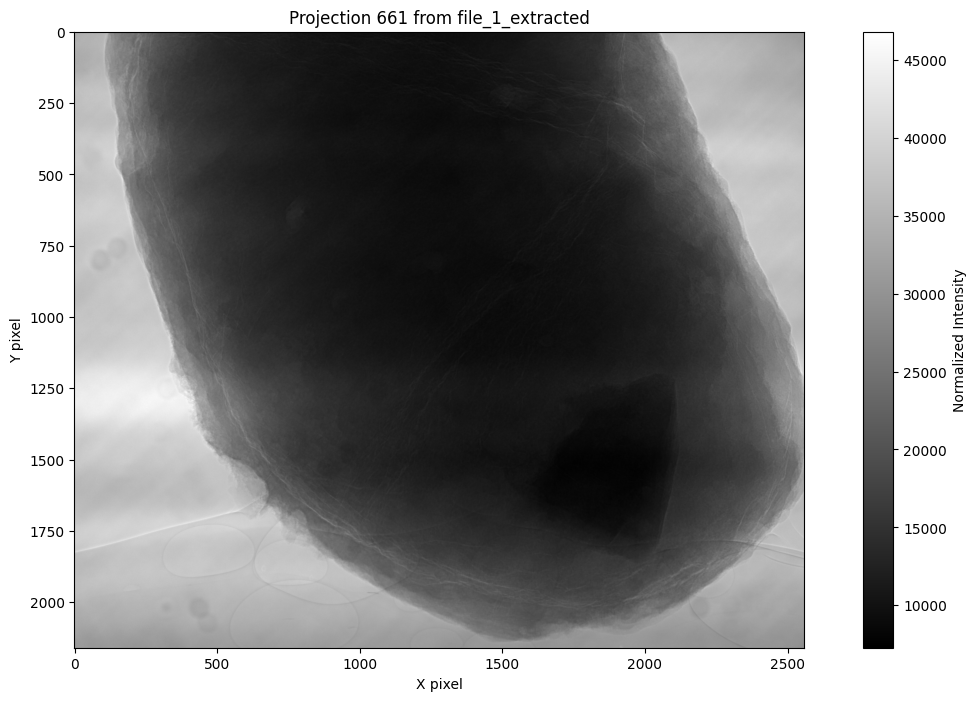

In [6]:
# Load and visualize a single projection
if demo_folder is not None:
    proj_idx = min(661, processor.num_projections - 1)  # Choose a projection index
    
    # Get the projection (normalized to [0, 1])
    projection = processor.get_projection(proj_idx, normalize=False)
    
    print(f"Projection {proj_idx}:")
    print(f"  Shape: {projection.shape}")
    print(f"  Range: [{projection.min():.4f}, {projection.max():.4f}]")
    
    # Visualize
    plt.figure(figsize=(15, 8))
    plt.imshow(projection)
    plt.colorbar(label='Normalized Intensity')
    plt.title(f'Projection {proj_idx} from {demo_folder.name}')
    plt.xlabel('X pixel')
    plt.ylabel('Y pixel')
    plt.show()

## 4. Creating the Dataset

The `ProjectionTripletDataset` creates sequences of consecutive projections for Noise2Noise training:
- **Input**: Stack of k consecutive projections P_i, P_{i+1}, ..., P_{i+k-1} (k channels)
- **Target**: Next projection P_{i+k} (1 channel)

The number of input projections k is controlled by the `num_input_projections` parameter (default=2).

In [22]:
# Create the dataset
# Note: num_darks and num_flats can be set to None for auto-detection from log file

NUM_INPUT_PROJECTIONS = 3  # Number of input channels (k). Target is the (k+1)-th projection.

dataset = ProjectionTripletDataset(
    folder_paths=DATA_PATH,
    target_size=TARGET_SIZE,
    num_darks=None,  # Auto-detect from log file
    num_flats=None,  # Auto-detect from log file
    epsilon=1e-6,
    cache_in_memory=False,
    preload=False,
    augment=False,  # Set to True for training
    verbose=True,
    use_attenuation=False,
    num_input_projections=NUM_INPUT_PROJECTIONS
)

print(f"\n📊 Dataset Statistics:")
print(f"   Total samples: {len(dataset)}")
print(f"   Input projections per sample (k): {NUM_INPUT_PROJECTIONS}")
print(f"   Target size: {TARGET_SIZE} × {TARGET_SIZE}")

✅ Found parameters in JC_62d.log: {'num_darks': 10, 'num_flats': 100, 'num_projections': 1501}
📂 Loaded folder: file_1_extracted
   Total TIFF files: 1711
   Darks: 10, Flats: 100, Projections: 1501
   Image dimensions: 2560 x 2160
   Use attenuation: False
✅ Loaded cached raw data from .tomography_cache_raw.npz
   Range: [6814.0000, 51523.0000]
✅ Found parameters in PD1511_41_.log: {'num_darks': 10, 'num_flats': 100, 'num_projections': 1501}
📂 Loaded folder: file_2_extracted
   Total TIFF files: 1711
   Darks: 10, Flats: 100, Projections: 1501
   Image dimensions: 2560 x 2160
   Use attenuation: False
✅ Loaded cached raw data from .tomography_cache_raw.npz
   Range: [5944.0000, 52770.0000]
✅ Found parameters in MI04_02.log: {'num_darks': 50, 'num_flats': 100, 'num_projections': 501}
📂 Loaded folder: file_3_extracted
   Total TIFF files: 751
   Darks: 50, Flats: 100, Projections: 501
   Image dimensions: 1008 x 1900
   Use attenuation: False
✅ Loaded cached raw data from .tomography_ca

In [23]:
import random
# Get a sample from the dataset
sample_idx = random.randint(0, len(dataset) - 1)
sample = dataset[sample_idx]

print(f"Sample {sample_idx}:")
print(f"  Input shape: {sample['input'].shape}  (k={NUM_INPUT_PROJECTIONS} channels)")
print(f"  Target shape: {sample['target'].shape}")
print(f"  Center coords: {sample['center_coords']}")
print(f"  Folder: {sample['folder_name']}")
print(f"  Target projection index: {sample['projection_idx']}")
print(f"\nTensor info:")
print(f"  Input: {sample['input']}")
print(f"  Target: {sample['target']}")

Sample 2375:
  Input shape: torch.Size([3, 512, 512])  (k=3 channels)
  Target shape: torch.Size([1, 512, 512])
  Center coords: tensor[2] μ=-0.407 σ=0.297 [-0.197, -0.617]
  Folder: file_2_extracted
  Target projection index: 880

Tensor info:
  Input: tensor[3, 512, 512] n=786432 (3Mb) x∈[0.092, 0.593] μ=0.200 σ=0.088
  Target: tensor[1, 512, 512] n=262144 (1Mb) x∈[0.093, 0.580] μ=0.200 σ=0.088


/tmp/ipykernel_2787/2931677807.py:27: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  vmax_diff = np.abs(diff).max()


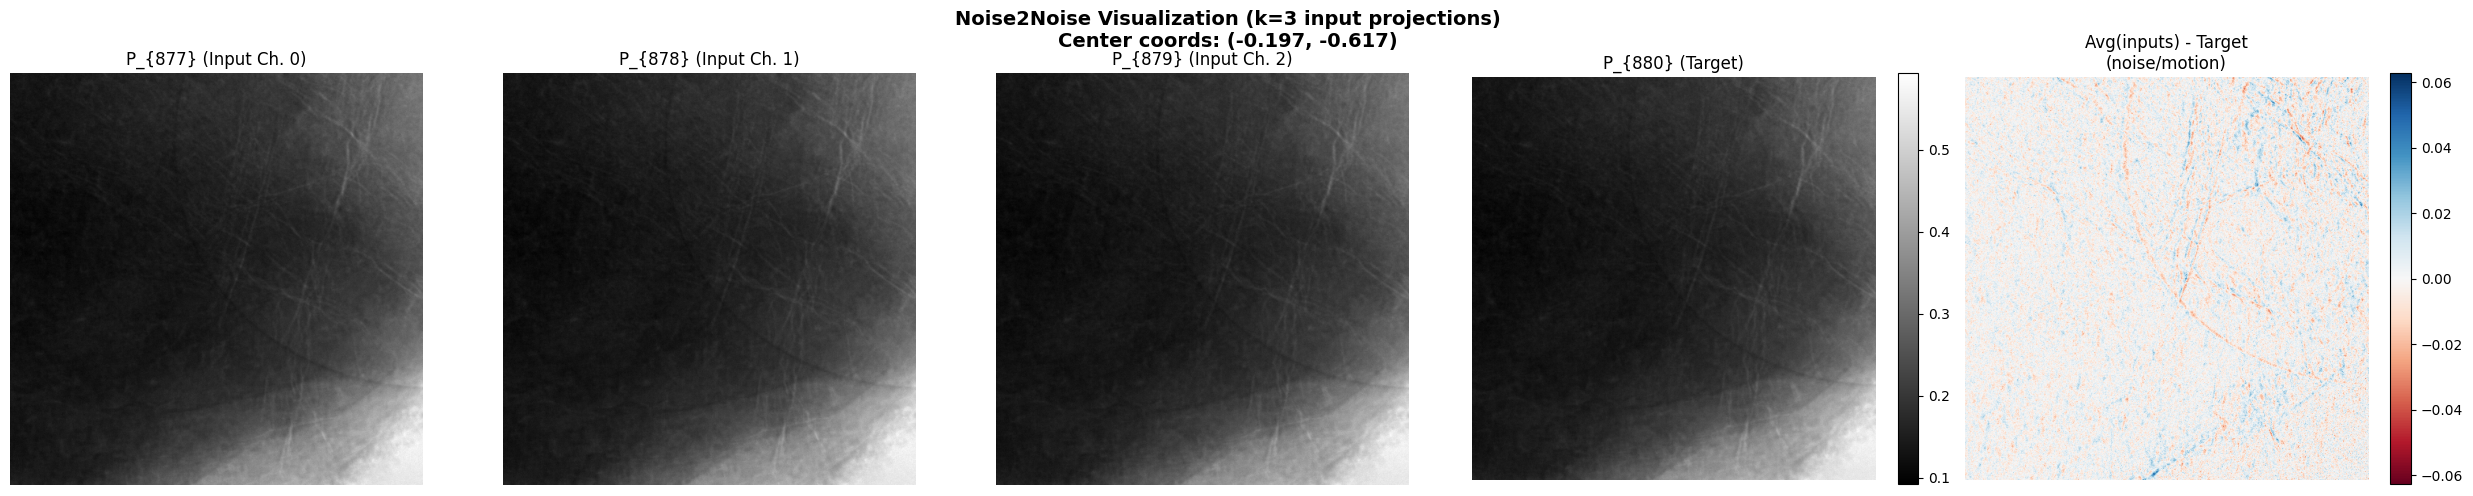

In [25]:
# Visualize the input projections and target
k = NUM_INPUT_PROJECTIONS
num_cols = k + 2  # k input channels + target + difference
fig, axes = plt.subplots(1, num_cols, figsize=(5 * num_cols, 5))

range_min = sample['input'].min()
range_max = sample['input'].max()

target_proj_idx = sample['projection_idx']

# Plot each input channel
for ch in range(k):
    axes[ch].imshow(sample['input'][ch].numpy(), vmin=range_min, vmax=range_max)
    input_proj_idx = target_proj_idx - k + ch
    axes[ch].set_title(f'P_{{{input_proj_idx}}} (Input Ch. {ch})')
    axes[ch].axis('off')

# Target projection
im_target = axes[k].imshow(sample['target'][0].numpy(), vmin=range_min, vmax=range_max)
axes[k].set_title(f'P_{{{target_proj_idx}}} (Target)')
axes[k].axis('off')
plt.colorbar(im_target, ax=axes[k], fraction=0.046)

# Difference between average of inputs and target
input_avg = sample['input'][0]
diff = input_avg - sample['target'][0]
vmax_diff = np.abs(diff).max()
im_diff = axes[k + 1].imshow(diff, cmap='RdBu', vmin=-vmax_diff, vmax=vmax_diff)
axes[k + 1].set_title(f'Avg(inputs) - Target\n(noise/motion)')
axes[k + 1].axis('off')
plt.colorbar(im_diff, ax=axes[k + 1], fraction=0.046)

plt.suptitle(f'Noise2Noise Visualization (k={k} input projections)\nCenter coords: ({sample["center_coords"][0]:.3f}, {sample["center_coords"][1]:.3f})', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Understanding Crop/Pad and Center Coordinates

The dataset standardizes all images to `target_size × target_size` by cropping (if larger) or padding (if smaller). The center coordinates tell us where the original image center lies within the processed image.

In [10]:
# Get original dimensions
orig_h, orig_w = dataset.get_original_dimensions(sample_idx)
center_coords = sample['center_coords'].numpy()

print(f"📐 Dimension Analysis:")
print(f"   Original size: {orig_w} × {orig_h}")
print(f"   Target size: {TARGET_SIZE} × {TARGET_SIZE}")
print(f"   Center coordinates (normalized): ({center_coords[0]:.4f}, {center_coords[1]:.4f})")
print(f"   Center coordinates (pixels): ({center_coords[0] * TARGET_SIZE:.1f}, {center_coords[1] * TARGET_SIZE:.1f})")

# Determine if cropped or padded
if orig_w > TARGET_SIZE:
    print(f"   Width: CROPPED by {orig_w - TARGET_SIZE} pixels")
elif orig_w < TARGET_SIZE:
    print(f"   Width: PADDED by {TARGET_SIZE - orig_w} pixels")
else:
    print(f"   Width: Unchanged")

if orig_h > TARGET_SIZE:
    print(f"   Height: CROPPED by {orig_h - TARGET_SIZE} pixels")
elif orig_h < TARGET_SIZE:
    print(f"   Height: PADDED by {TARGET_SIZE - orig_h} pixels")
else:
    print(f"   Height: Unchanged")

📐 Dimension Analysis:
   Original size: 2560 × 2160
   Target size: 512 × 512
   Center coordinates (normalized): (-1.2363, -0.2383)
   Center coordinates (pixels): (-633.0, -122.0)
   Width: CROPPED by 2048 pixels
   Height: CROPPED by 1648 pixels


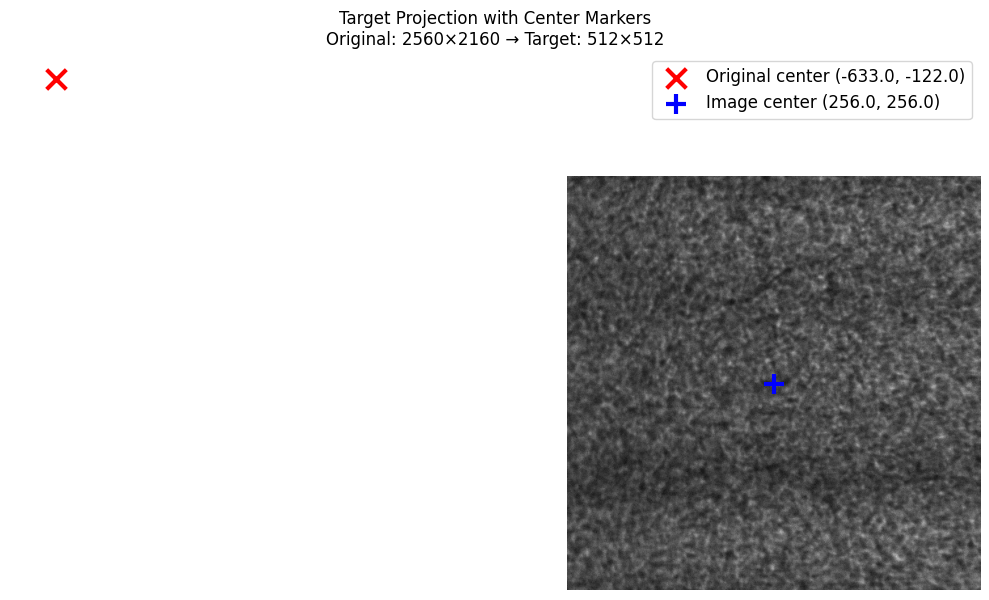

In [11]:
# Visualize the center position
fig, ax = plt.subplots(figsize=(10, 10))

ax.imshow(sample['target'][0].numpy(), vmin=0, vmax=1)

# Mark the center of the original image
cx, cy = center_coords[0] * TARGET_SIZE, center_coords[1] * TARGET_SIZE
ax.scatter([cx], [cy], c='red', s=200, marker='x', linewidths=3, 
           label=f'Original center ({cx:.1f}, {cy:.1f})')

# Mark the center of the processed image
ax.scatter([TARGET_SIZE/2], [TARGET_SIZE/2], c='blue', s=200, marker='+', linewidths=3,
           label=f'Image center ({TARGET_SIZE/2}, {TARGET_SIZE/2})')

ax.legend(loc='upper right', fontsize=12)
ax.set_title(f'Target Projection with Center Markers\nOriginal: {orig_w}×{orig_h} → Target: {TARGET_SIZE}×{TARGET_SIZE}', 
             fontsize=12)
ax.axis('off')
plt.tight_layout()
plt.show()

## 6. Creating Train/Validation Split

In [12]:
# Split into training and validation sets
train_dataset, val_dataset = create_train_val_split(
    dataset,
    val_ratio=0.1,  # 10% for validation
    seed=42
)

print(f"📊 Dataset Split:")
print(f"   Total samples: {len(dataset)}")
print(f"   Training samples: {len(train_dataset)} ({100*len(train_dataset)/len(dataset):.1f}%)")
print(f"   Validation samples: {len(val_dataset)} ({100*len(val_dataset)/len(dataset):.1f}%)")

📊 Dataset Split:
   Total samples: 12988
   Training samples: 11690 (90.0%)
   Validation samples: 1298 (10.0%)


## 7. Creating DataLoaders

In [13]:
# Create DataLoaders for training
BATCH_SIZE = 2  # Adjust based on GPU memory (2048×2048 images are large!)
NUM_WORKERS = 4

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

print(f"📦 DataLoaders created:")
print(f"   Batch size: {BATCH_SIZE}")
print(f"   Training batches: {len(train_loader)}")
print(f"   Validation batches: {len(val_loader)}")

📦 DataLoaders created:
   Batch size: 2
   Training batches: 5845
   Validation batches: 649


In [14]:
# Test loading a batch
print("Loading a batch...")
batch = next(iter(train_loader))

print(f"\n📦 Batch Contents:")
print(f"   Input shape: {batch['input'].shape}")
print(f"   Target shape: {batch['target'].shape}")
print(f"   Center coords shape: {batch['center_coords'].shape}")
print(f"   Folder names: {batch['folder_name']}")
print(f"   Projection indices: {batch['projection_idx']}")

# Memory estimate
input_memory = batch['input'].element_size() * batch['input'].nelement() / 1e6
target_memory = batch['target'].element_size() * batch['target'].nelement() / 1e6
print(f"\n💾 Memory per batch:")
print(f"   Input: {input_memory:.1f} MB")
print(f"   Target: {target_memory:.1f} MB")
print(f"   Total: {input_memory + target_memory:.1f} MB")

Loading a batch...

📦 Batch Contents:
   Input shape: torch.Size([2, 2, 512, 512])
   Target shape: torch.Size([2, 1, 512, 512])
   Center coords shape: torch.Size([2, 2])
   Folder names: ['file_2_extracted', 'file_2_extracted']
   Projection indices: tensor[2] i64 μ=556.500 σ=703.571 [1054, 59]

💾 Memory per batch:
   Input: 4.2 MB
   Target: 2.1 MB
   Total: 6.3 MB


## 8. Model Setup (UNet2DModel from Diffusers)

In [62]:
from diffusers import UNet2DModel

# Create the UNet model
model = UNet2DModel(
    sample_size=TARGET_SIZE,  # the target image resolution
    in_channels=NUM_INPUT_PROJECTIONS,  # k input channels: P_i, P_{i+1}, ..., P_{i+k-1}
    out_channels=1,  # 1 output channel: predicted P_{i+k}
    layers_per_block=2,  # ResNet layers per UNet block
    block_out_channels=(64, 64, 128, 128, 256, 256),  # channels for each block
    down_block_types=(
        "DownBlock2D",
        "DownBlock2D",
        "DownBlock2D",
        "DownBlock2D",
        "AttnDownBlock2D",  # attention block
        "DownBlock2D",
    ),
    up_block_types=(
        "UpBlock2D",
        "AttnUpBlock2D",  # attention block
        "UpBlock2D",
        "UpBlock2D",
        "UpBlock2D",
        "UpBlock2D",
    ),
)

# Count parameters
num_params = sum(p.numel() for p in model.parameters())
num_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"🏗️  Model Summary:")
print(f"   Total parameters: {num_params:,}")
print(f"   Trainable parameters: {num_trainable:,}")
print(f"   Input channels: {NUM_INPUT_PROJECTIONS}")
print(f"   Output channels: 1")
print(f"   Sample size: {TARGET_SIZE}×{TARGET_SIZE}")

# Load trained model weights if available
checkpoint_path = Path("../checkpoints/best_model.pt")
if checkpoint_path.exists():
    print(f"\n📂 Loading trained model from {checkpoint_path}")
    checkpoint = torch.load(checkpoint_path, map_location='cpu')
    model.load_state_dict(checkpoint['model_state_dict'])
    epoch = checkpoint['epoch']
    val_loss = checkpoint.get('best_val_loss', 'N/A')
    print(f"   ✅ Loaded checkpoint from epoch {epoch}")
    print(f"   Validation loss: {val_loss}")
else:
    print(f"\n⚠️  No trained model found at {checkpoint_path}")
    print(f"   Using untrained model (random weights)")

🏗️  Model Summary:
   Total parameters: 28,446,081
   Trainable parameters: 28,446,081
   Input channels: 3
   Output channels: 1
   Sample size: 512×512

📂 Loading trained model from ../checkpoints/best_model.pt
   ✅ Loaded checkpoint from epoch 27
   Validation loss: 0.00036472078412501743


In [64]:
# Test forward pass
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

model = model.to(device)

# Create a small test batch
with torch.no_grad():
    test_input = batch['input'][:1].to(device)  # Use just 1 sample
    
    # UNet2DModel expects a timestep argument (we use 0 for non-diffusion)
    timesteps = torch.zeros(1, dtype=torch.long, device=device)
    
    output = model(test_input, timesteps, return_dict=False)[0]
    
    print(f"✅ Forward pass successful!")
    print(f"   Input shape: {test_input.shape}")
    print(f"   Output shape: {output.shape}")

Device: cuda
✅ Forward pass successful!
   Input shape: torch.Size([1, 3, 512, 512])
   Output shape: torch.Size([1, 1, 512, 512])


## 10. Visualize Model Prediction (Untrained)

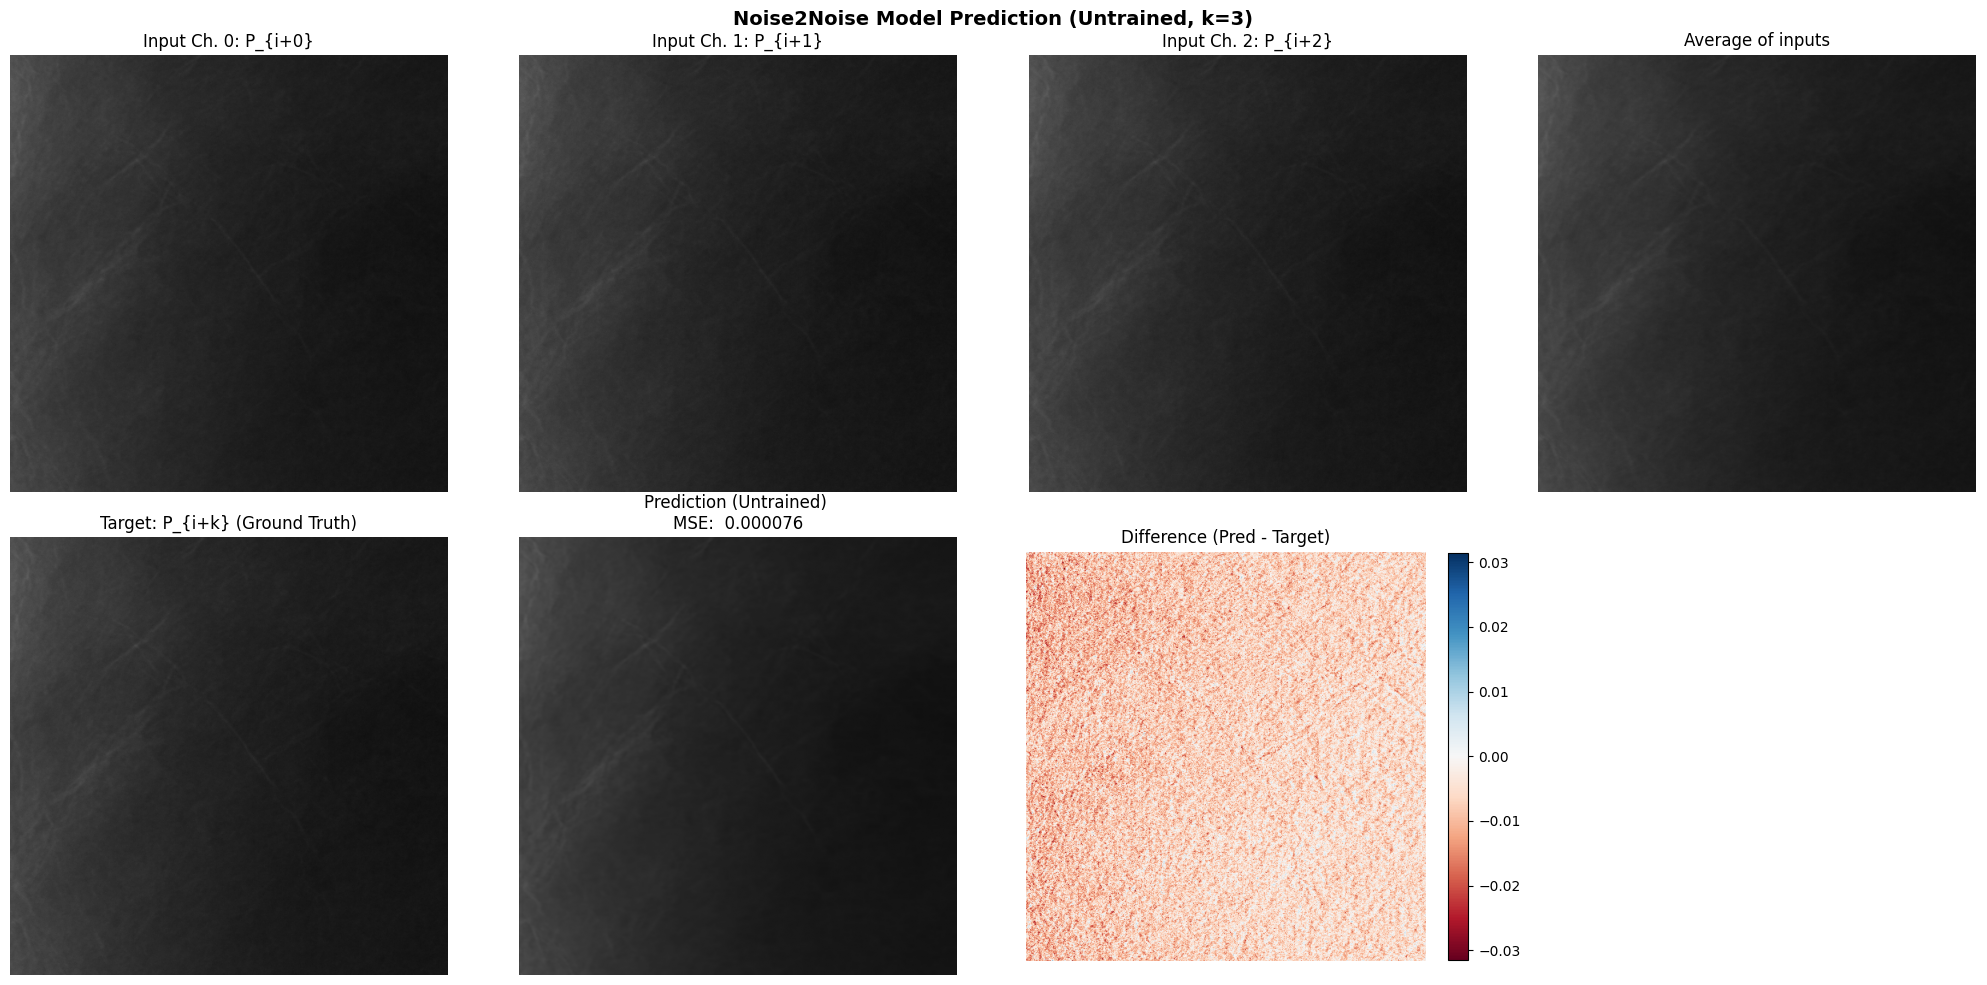

In [65]:
# Get a prediction from the (mostly untrained) model
model.eval()

with torch.no_grad():
    sample = dataset[100]
    input_tensor = sample['input'].unsqueeze(0).to(device)
    target_tensor = sample['target'].unsqueeze(0).to(device)
    
    timesteps = torch.zeros(1, dtype=torch.long, device=device)
    pred = model(input_tensor, timesteps, return_dict=False)[0]
    
    # Compute MSE
    mse = torch.nn.functional.mse_loss(pred, target_tensor).item()

# Visualize
k = NUM_INPUT_PROJECTIONS
num_top_cols = k + 1  # k inputs + average
num_bot_cols = 3      # target, prediction, difference
num_cols = max(num_top_cols, num_bot_cols)
fig, axes = plt.subplots(2, num_cols, figsize=(5 * num_cols, 10))

# Hide unused axes
for ax_row in axes:
    for ax in ax_row:
        ax.axis('off')

# Top row: input channels + average
for ch in range(k):
    axes[0, ch].imshow(sample['input'][ch].numpy(), vmin=0, vmax=1)
    axes[0, ch].set_title(f'Input Ch. {ch}: P_{{i+{ch}}}')
    axes[0, ch].axis('off')

# Average of inputs
input_avg = sample['input'].mean(dim=0)
axes[0, k].imshow(input_avg.numpy(), vmin=0, vmax=1)
axes[0, k].set_title('Average of inputs')
axes[0, k].axis('off')

# Bottom row: target, prediction, difference
axes[1, 0].imshow(sample['target'][0].numpy(), vmin=0, vmax=1)
axes[1, 0].set_title('Target: P_{i+k} (Ground Truth)')
axes[1, 0].axis('off')

im = axes [1, 1]. imshow(pred [0, 0] .cpu().numpy(), vmin=0, vmax=1)
axes [1, 1]. imshow(pred [0, 0].cpu( ).numpy(), vmin=0, vmax=1)
axes [1, 1].set_title(f'Prediction (Untrained) \nMSE: {mse: .6f}')
axes [1, 1].axis( 'off')
# Difference
padding = 6
diff = (pred[0, 0, :, padding:-padding].cpu() - sample['target'][0][:, padding:-padding]).numpy()
vmax = np.abs(diff).max()
im = axes[1, 2].imshow(diff, cmap='RdBu', vmin=-vmax, vmax=vmax)
axes[1, 2].set_title('Difference (Pred - Target)')
axes[1, 2].axis('off')
plt.colorbar(im, ax=axes[1, 2], fraction=0.046)

plt.suptitle(f'Noise2Noise Model Prediction (Untrained, k={k})', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 11. Data Loading Speed Test

In [66]:
import time

# Test data loading speed
print("⏱️  Testing data loading speed...")

num_batches_to_test = 10

# Warm up
_ = next(iter(train_loader))

# Time loading
start_time = time.time()
for i, batch in enumerate(train_loader):
    if i >= num_batches_to_test:
        break
elapsed = time.time() - start_time

batches_per_sec = num_batches_to_test / elapsed
samples_per_sec = num_batches_to_test * BATCH_SIZE / elapsed

print(f"\n📊 Data Loading Performance:")
print(f"   Batches loaded: {num_batches_to_test}")
print(f"   Time elapsed: {elapsed:.2f}s")
print(f"   Batches/second: {batches_per_sec:.2f}")
print(f"   Samples/second: {samples_per_sec:.2f}")

# Estimate epoch time
est_epoch_time = len(train_loader) / batches_per_sec
print(f"\n   Estimated time per epoch: {est_epoch_time/60:.1f} minutes")

if samples_per_sec < 1:
    print(f"\n⚠️  Data loading is slow! Consider:")
    print(f"   - Setting cache_in_memory=True")
    print(f"   - Using preload=True")
    print(f"   - Increasing num_workers")

⏱️  Testing data loading speed...

📊 Data Loading Performance:
   Batches loaded: 10
   Time elapsed: 19.56s
   Batches/second: 0.51
   Samples/second: 1.02

   Estimated time per epoch: 190.4 minutes


## 12. Summary and Next Steps

### What we covered:
1. **TomographyFolderProcessor**: Handles dark/flat correction and attenuation calculation
2. **ProjectionTripletDataset**: Creates triplets for Noise2Noise training
3. **Crop/Pad standardization**: All images are normalized to `target_size × target_size`
4. **Center coordinates**: Track the original image center position for conditioning
5. **UNet2DModel**: The denoising model architecture

### Training the model:
Use the training script:
```bash
python scripts/train_noise2noise_denoising.py \
    --data_path /path/to/folder1 /path/to/folder2 \
    --target_size 2048 \
    --batch_size 2 \
    --epochs 100 \
    --learning_rate 1e-4 \
    --augment \
    --wandb
```

### Tips:
- Use `cache_in_memory=True` for faster training if you have enough RAM
- Start with a smaller `target_size` (e.g., 512 or 1024) for testing
- Use `augment=True` during training for better generalization
- Monitor validation loss to detect overfitting

In [67]:
import sys, tempfile 
from pathlib import Path
sys.path. insert(0, str(Path.cwd().parent) )
from compress_ct import CTCompressor, CTDecompressor 
from compress_ct.predictor import BlockPredictor
# ---- Build the predictor from the trained model ----
# Re-use the model object already loaded above (Section 8).
# It was trained at target_size=512, but we feed 256x256 patches.
predictor = BlockPredictor(
    model=model, 
    block_size=256, 
    num_input_projections=NUM_INPUT_PROJECTIONS, 
    device=device, overlap=32,
)
# --- Collect a small sequence of frames from the dataset ----
# We'll take 8 consecutive projections from the first folder
n_demo_frames = 8
processor = dataset.processors[0]
demo_frames = [
    processor.get_projection(20 + i, normalize=True) 
    for i in range(n_demo_frames)
]
print(f"Collected {len(demo_frames)} frames, shape {demo_frames[0].shape}")
# ---- Compress ----
compressor = CTCompressor (
    predictor=predictor, 
    patch_size=256, 
    residual_quality=100, 
    jpeg_quality=100, 
    dct_block_size=8,
    fallback_threshold=None, # keep whichever is smaller automatically 
    verbose=True,
)
archive_path = Path(tempfile.mktemp(suffix=".ctc"))
stats = compressor. compress (demo_frames, archive_path)
print(f"\nArchive size: {archive_path.stat().st_size:,} bytes")
print(f"Compression ratio: {stats ['compression_ratio']:.2f}x")

Collected 8 frames, shape (2160, 2560)
  Frame    0  INTRA   2,266,697 B
  Frame    1  INTRA   2,265,031 B
  Frame    2  INTRA   2,264,936 B


Compressing: 100%|██████████| 5/5 [00:26<00:00,  5.20s/frame]


✅ Compressed 8 frames (2160×2560) → 10,564,220 bytes
   Compression ratio: 16.75x
   Residual patches: 450, JPEG fallbacks: 0

Archive size: 10,564,220 bytes
Compression ratio: 16.75x


📂 Archive: tmp0stsz_ps.ctc
   Frames: 8, Size: 2160×2560, k=3
   Patch: 256, DCT block: 8
   Residual quality: 100, JPEG quality: 100
   Conditioning: OFF


Decompressing: 100%|██████████| 8/8 [00:14<00:00,  1.85s/frame]


✅ Decompressed 8 frames (2160×2560)


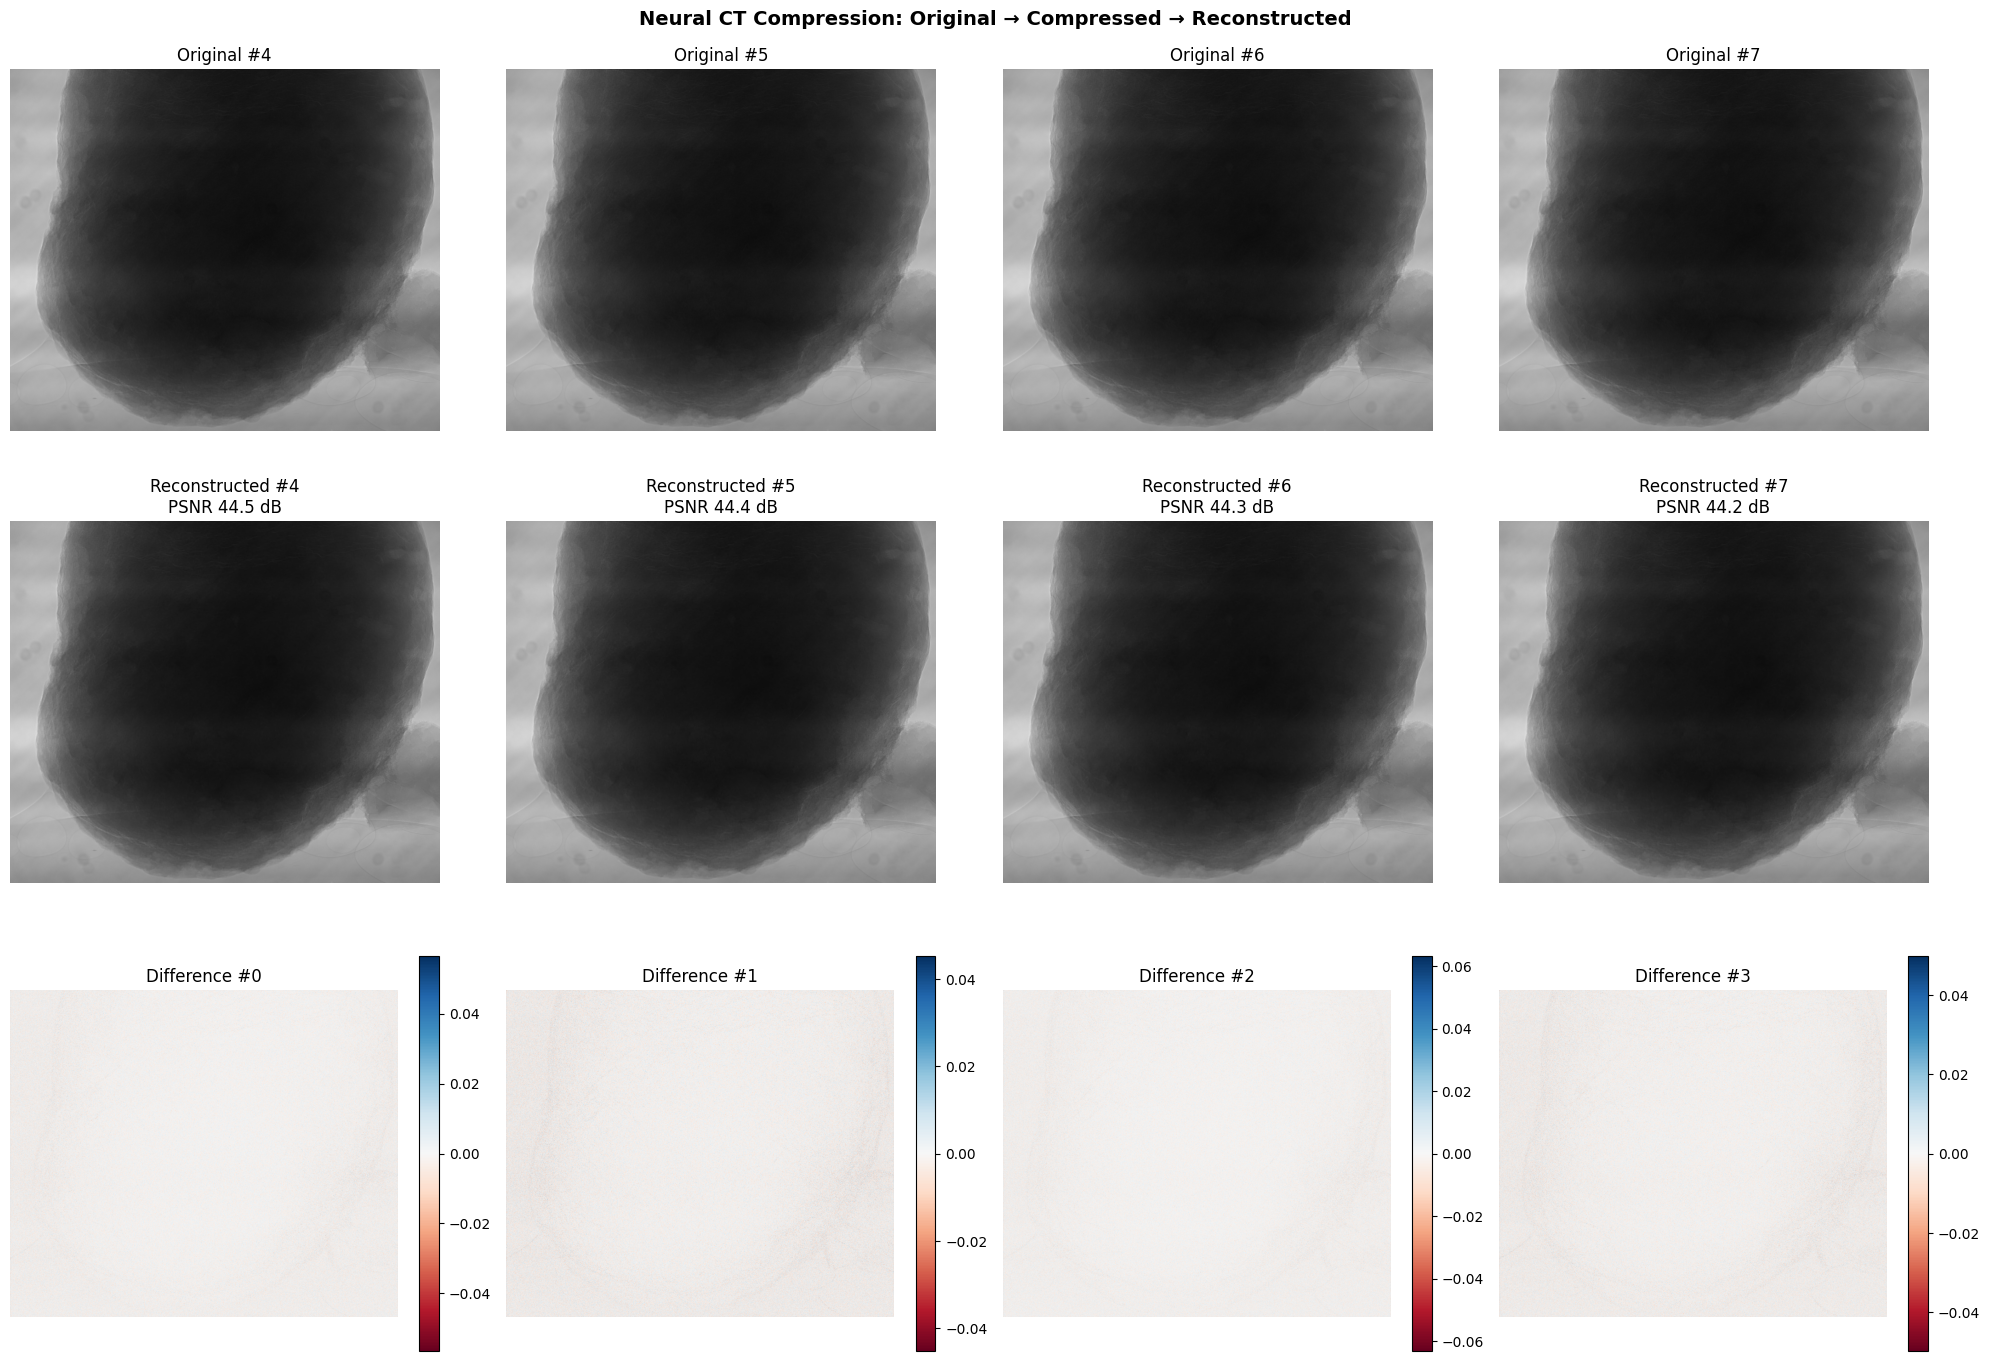


Per-frame statistics:
 Frame      Bytes   Residual       JPEG    JPEG FB
     0    2248465          0          0
     1    2258309          0          0
     2    2259171          0          0
     3     768630         90          0
     4     776634         90          0
     5     779259         90          0
     6     777441         90          0
     7     778504         90          0


In [55]:
# -- Decompress ----
decompressor = CTDecompressor (predictor=predictor, verbose=True)
recovered = decompressor.decompress(archive_path)
# ---- Compare original vs. reconstructed ----
n_show = min(4, n_demo_frames)
fig, axes = plt.subplots(3, n_show, figsize=(5 * n_show, 14))
for i, j in enumerate(range(4, 4+n_show)):
    # Original
    axes[0, i].imshow(demo_frames[j], vmin=0, vmax=1)
    axes[0, i].set_title(f"Original #{j}")
    axes[0, i].axis("off")
    # Reconstructed
    axes[1, i].imshow(recovered[j], vmin=0, vmax=1)
    mse_val = np.mean((demo_frames[j] - recovered[j]) ** 2)
    psnr_val = 10 * np.log10(1.0 / max(mse_val, 1e-10))
    axes[1, i].set_title(f"Reconstructed #{j}\nPSNR {psnr_val:.1f} dB")
    axes[1, i].axis("off")
    # Difference (amplified)
    diff = demo_frames[j] - recovered[j]
    vmax = max(np.abs(diff).max(), 1e-6)
    im = axes[2, i].imshow(diff, cmap="RdBu", vmin=-vmax, vmax=vmax)
    axes[2, i].set_title(f"Difference #{i}")
    axes[2, i].axis("off")
    plt.colorbar(im, ax=axes[2, i], fraction=0.046)
plt.suptitle("Neural CT Compression: Original → Compressed → Reconstructed", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()
# Print per-frame stats
print ("\nPer-frame statistics:")
print (f"{'Frame':>6} {'Bytes':>10} {'Residual':>10} {'JPEG':>10} {'JPEG FB':>10}")
for i in range(len(stats ['frame_bytes'])):
    fb = stats ['fallback_counts'] [i]
    res = stats ['residual_counts'] [i]
    b = stats ['frame_bytes'] [i]
    print(f"{i:6d} {b:10d} {res:10d} {fb:10d}")
# Cleanup
# archive_path.unlink(missing_ok=True)

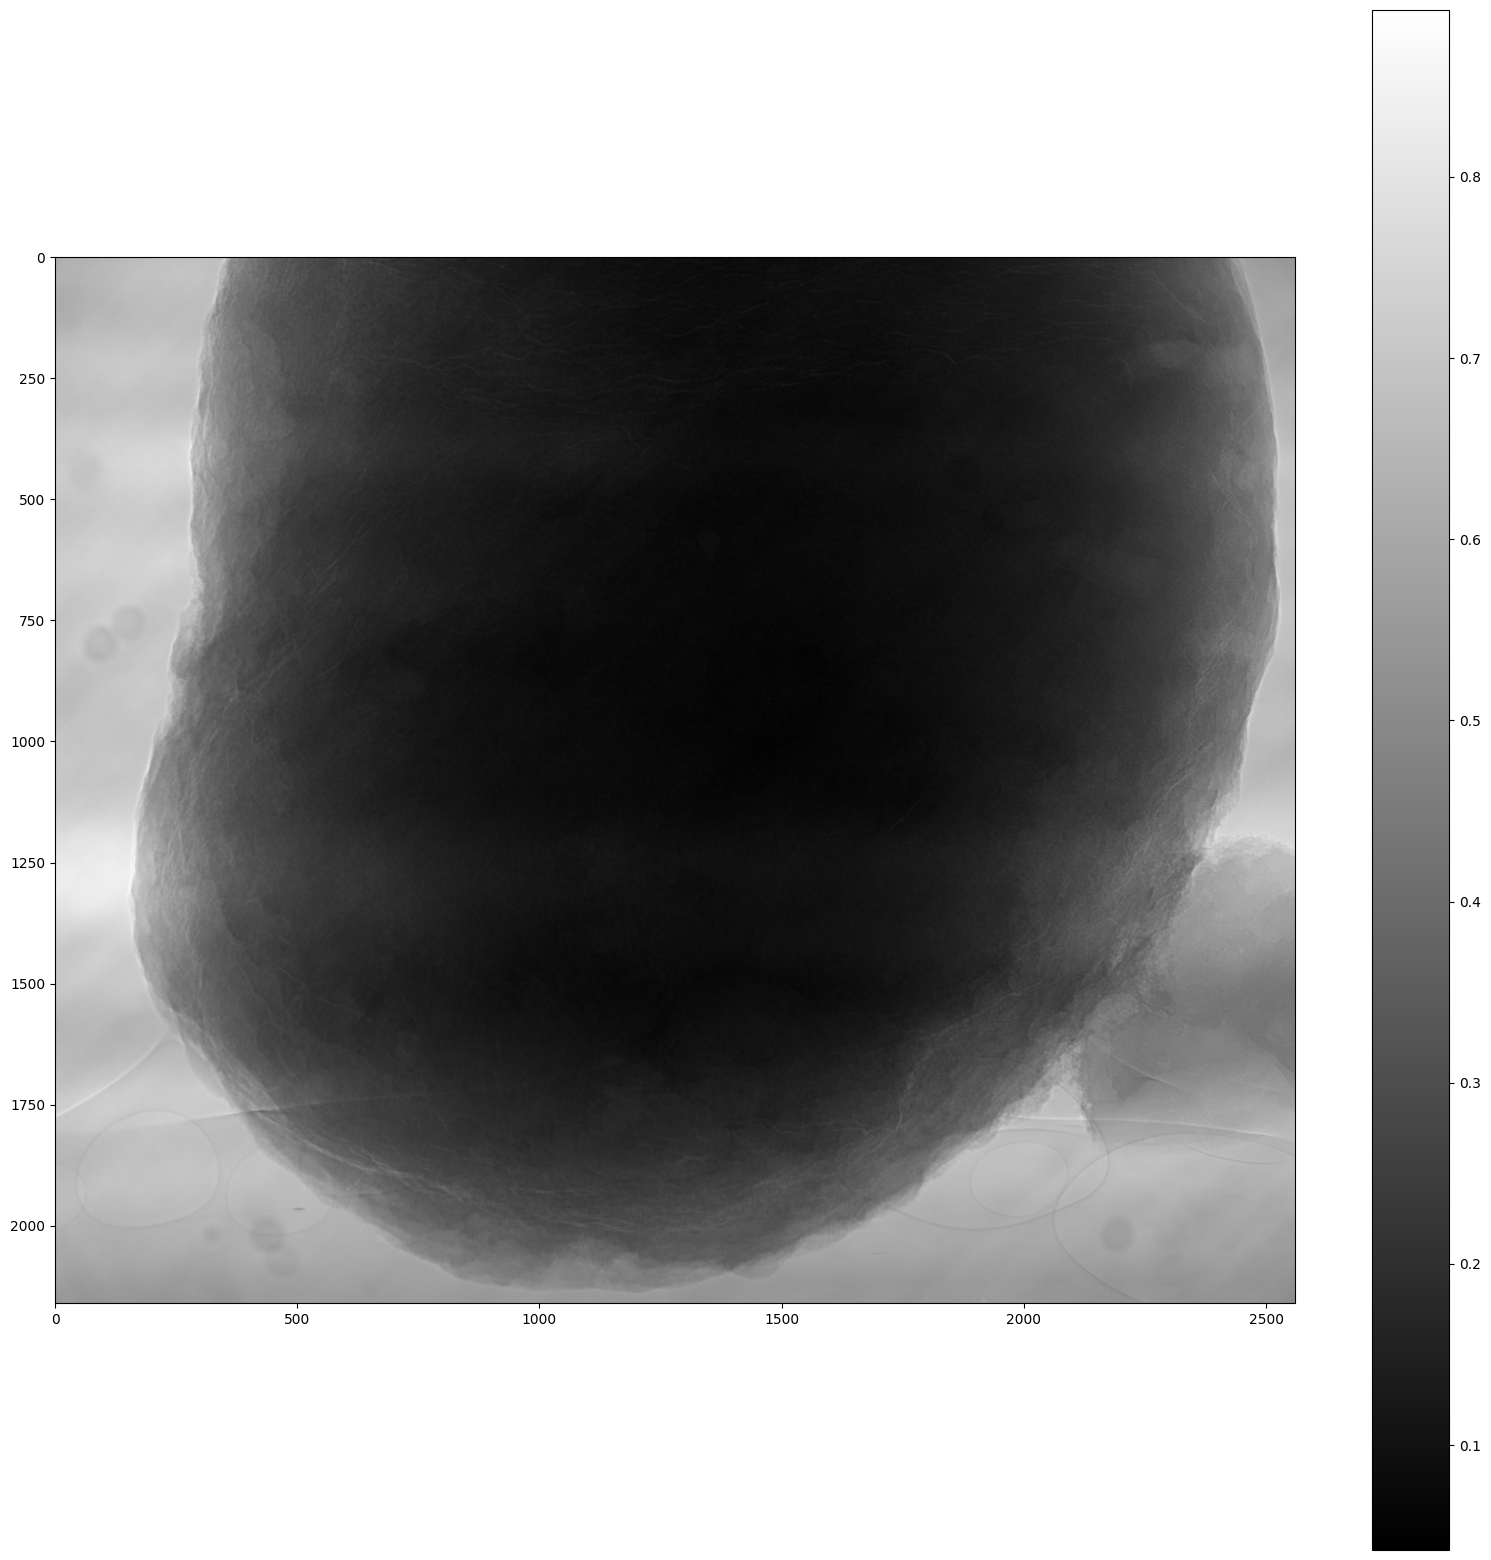

In [61]:
plt.figure(figsize=(20, 20))
plt.imshow(demo_frames[j])
plt.colorbar()

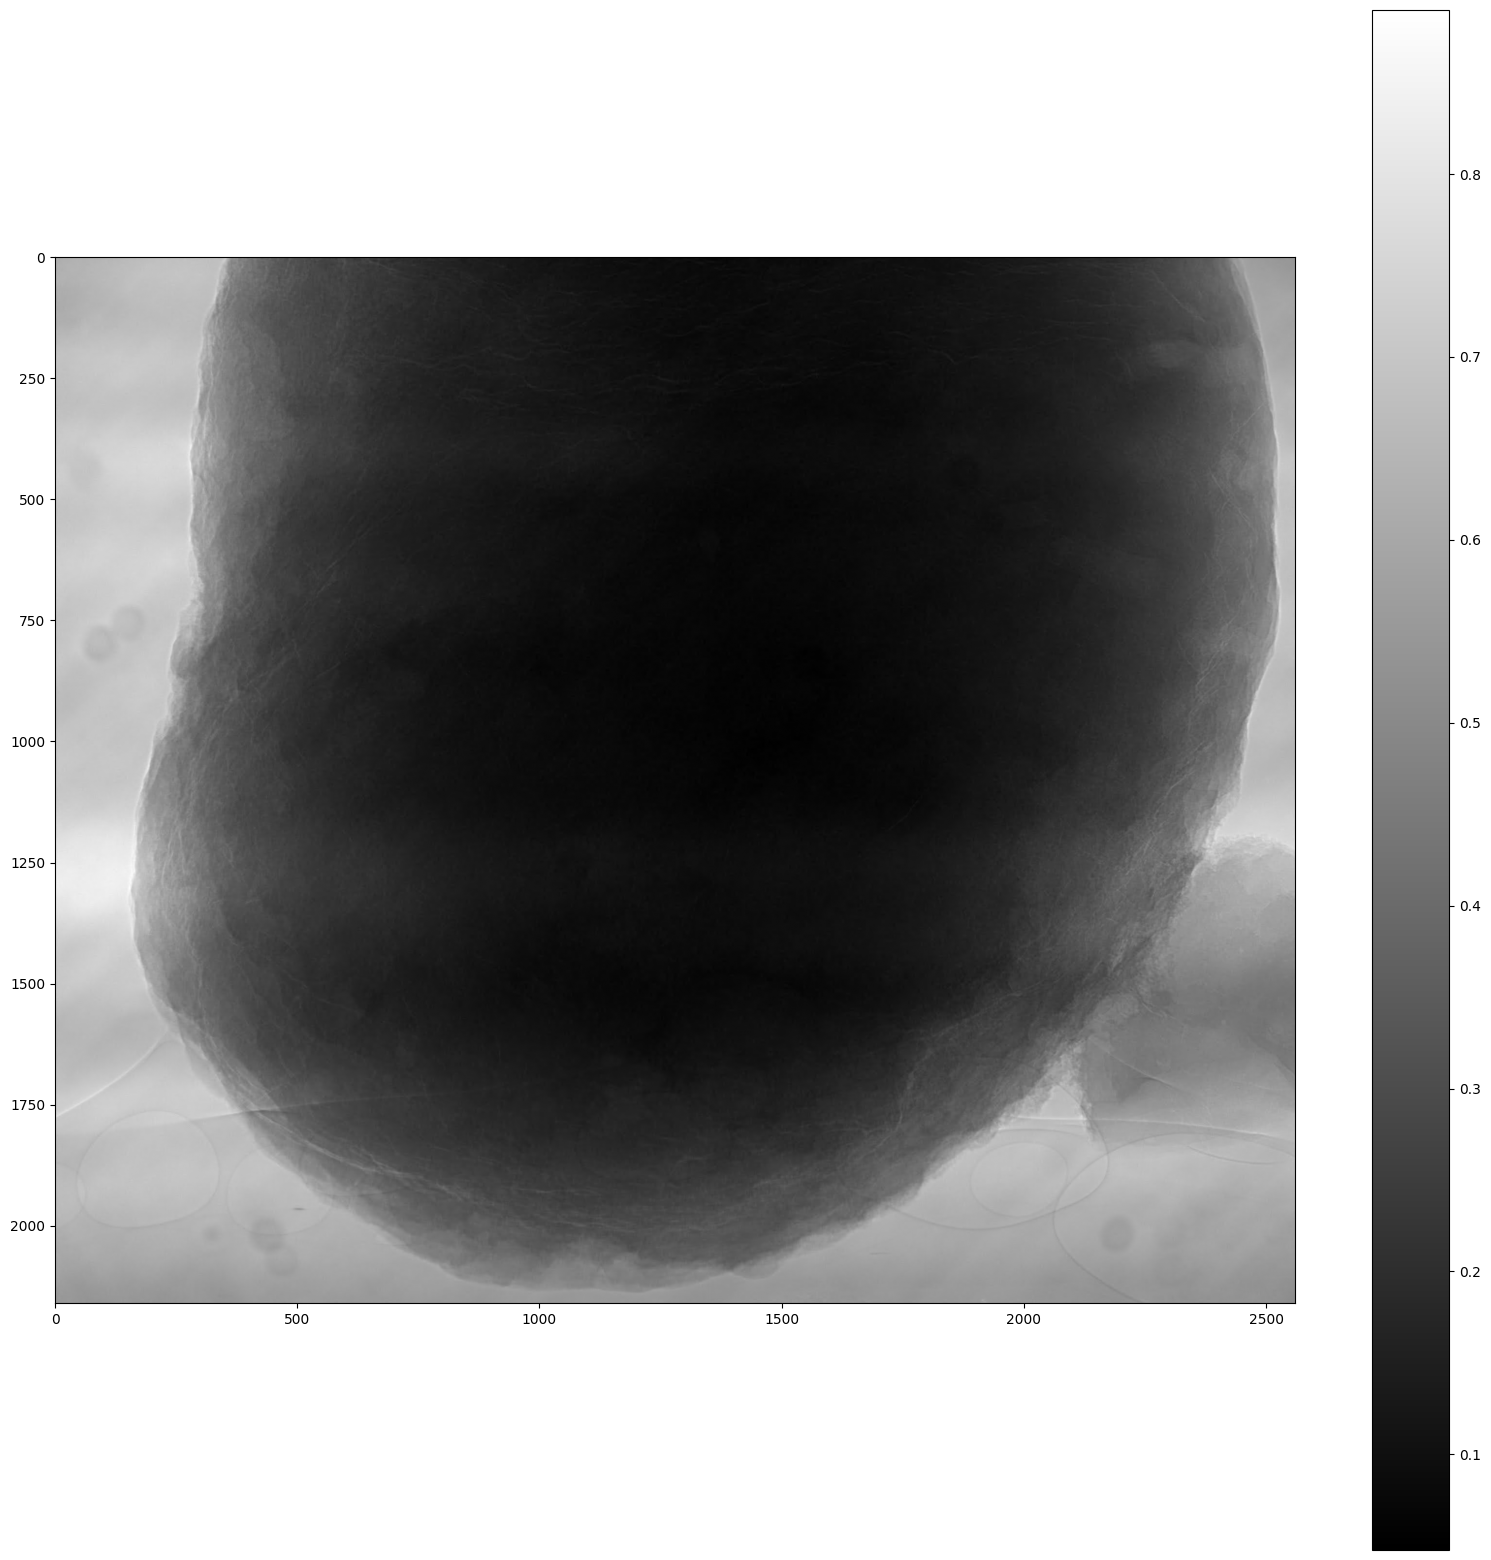

In [57]:
plt.figure(figsize=(20, 20))
plt.imshow(torch.tensor(recovered[j]))
plt.colorbar()